`conda activate spectra_v2`

In [1]:
import anndata as ad
import scanpy as sc
import pandas as pd
import numpy as np
import os
from matplotlib import rcParams
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
sc.settings.n_jobs = 20

In [3]:
rcParams["figure.figsize"] = (5, 5)

import warnings

warnings.simplefilter("ignore", category=UserWarning)

In [4]:
adata = sc.read('/projects/0/einf2548/cruiz/dmg/data/malignant_rna_raw_counts.h5ad')
adata

AnnData object with n_obs × n_vars = 291695 × 19248
    obs: 'nCount_RNA', 'nFeature_RNA', 'nCount_RAW', 'nFeature_RAW', 'DF.class', 'DF.score', 'scDblFinder.class', 'scDblFinder.score', 'ID', 'SampleID', 'Data', 'percent_mito', 'percent_ribo', 'percent_mito_ribo', 'log10GenesPerUMI', 'nFeature_Diff', 'nCount_Diff', 'Batch_for_correction', 'scDblFinder.clusters.class', 'scDblFinder.clusters.score', 'scDblFinder.class.clusters', 'doublet.combn.fisher', 'doublet.combn.mean', 'doublet.combn.fisher.class', 'doublet.combn.mean.class', 'Study', 'Original_annotation', 'Isolation_method_by_cell', 'Cell_type_granular_mouse_correlations', 'Cell_type_mouse_correlations', 'Cell_type_consensus_Jessa2022', 'Malignant_normal_consensus_Jessa2022', 'Institute', 'Preservation_method', 'Diagnosis', 'Tumor_type', 'Tumor_subtype', 'Location', 'Source', 'Clinical_status', 'Isolation_method', 'Sc_platform_RNA', 'Sc_platform_ATAC', 'Sc_multiome', 'Raw_data_available', 'Counts', 'Genome_version', 'Paired_sampl

In [9]:
nmf_meta = pd.read_csv('data/nmf_assigment_malignant_no_core_programs.csv', 
                       sep=',', index_col=0)
nmf_meta

,MP_Assignment
BT042_PD_CCGTTCATCTATGTGG-1,unresolved
BT042_PD_CTACCTGGTATGAAAC-1,MP_2
BT042_PD_TTGCATTTCCTGTAGA-1,MP_2
BT042_PD_GTGCTGGGTAACGCGA-1,MP_2
BT042_PD_CTTCTAAAGACGCATG-1,MP_2
...,...
multiome_P-6774_S-10146_TCAAGGAAGCGGATTT-1,MP_9
multiome_P-6774_S-10146_TCAGCGATCCGTGACA-1,MP_5
multiome_P-6774_S-10146_CGCTTACTCCGTTAAA-1,unresolved
multiome_P-6774_S-10146_CTTTATCAGGAAGCTA-1,unresolved


In [10]:
adata.obs['nmf'] = nmf_meta['MP_Assignment'].loc[adata.obs.index]

In [ ]:
adata_subset = adata[adata.obs['nmf'].isin(['MP_4','MP_13','MP_11','MP_2',
                            'MP_5',
                            'MP_3','MP_8',
                            'MP_12'])].copy() 
adata_subset

In [ ]:
import pandas as pd

# Ensure 'MP_Assignment' is categorical
adata_subset.obs['nmf'] = adata_subset.obs['nmf'].astype(pd.CategoricalDtype(categories=['MP_4','MP_13','MP_11','MP_12','MP_2',
                                                                                                           'MP_5','MP_3','MP_8'], 
                                                                                                ordered=True))

# Now the categories will be in the specified order
adata_subset

In [17]:
del(adata_subset.obs['EGFR'])
del(adata_subset.obs['PDGFRA'])

In [26]:
marker_genes_dict = {
    'RG': ['NES', 'FABP7'],
    'GBL': ['ABCA8', 'CRYAB'],
    'TriIPC': ['EGFR', 'HES6'],
    'nIPC': ['STMN2', 'MYT1L'],
    'OPC': ['PDGFRA', 'PCDH15'],
    'COP': ['BMPER', 'GPR17'],
    'AC': ['AQP4', 'GJA1'],
    'Cilia': ['DNAH5', 'CFAP157']
}

In [29]:
plt.rcParams['pdf.fonttype'] = 42
sc.settings.figdir = 'figures'

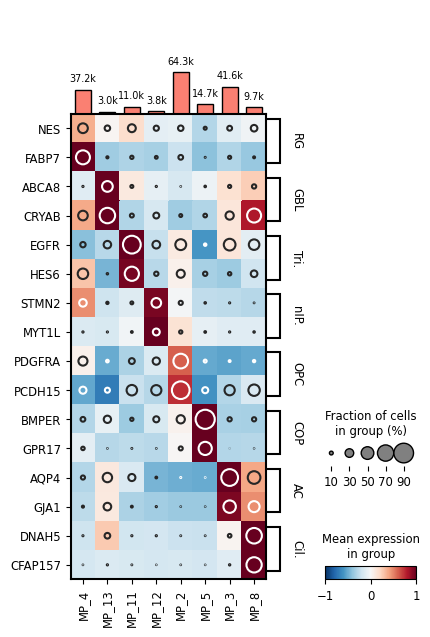

In [31]:
dp = sc.pl.dotplot(adata_subset, marker_genes_dict, groupby='nmf', return_fig=True,
             layer='scaled', vmin=-1, vmax=1, swap_axes= True, dendrogram=False)
dp.style(color_on='square', cmap='RdBu_r', dot_edge_color=None, dot_edge_lw=None, size_exponent=1.5)\
.add_totals().savefig('figures/heatmap_classical_developmental_markers_pDG_atlas.pdf')